In [21]:
import torch
import json
import matplotlib.pyplot as plt
import numpy as np
import tqdm
from collections import defaultdict
import pandas as pd
import re
import random
from sklearn.metrics import f1_score, classification_report, brier_score_loss
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from src.data import load_and_prepare_datasets
from src.utils import load_model
from src.gaussian_processes.prediction import predict_with_uncertainty
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [22]:
model, tokenizer = load_model("models/gp_finetune_weights/best", device=device)
model.eval()

[INFO] Loading model from: models/gp_finetune_weights/best


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


models/gp_finetune_weights/best\pytorch_model.bin
[INFO] Model loaded successfully.


DistilBERTWithGP(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Li

In [23]:
datasets, id2label = load_and_prepare_datasets(
    tokenizer=tokenizer,
)
 
test_set = datasets["test"]
print("Lenght of the test set:", len(test_set))

Jigsaw dataset already exists. Skipping download.


Map:   0%|          | 0/129251 [00:00<?, ? examples/s]

Map:   0%|          | 0/14362 [00:00<?, ? examples/s]

Map:   0%|          | 0/15958 [00:00<?, ? examples/s]

Lenght of the test set: 15958


In [24]:
i = 4
sample = test_set[i]
 
text = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)
label = sample["labels"]

print("======== EXAMPLE =========")
 
print("TEXT:", text)
print("TRUE LABELS:", label.numpy())
print("CLASS NAMES:", id2label)

print("\n MODEL PREDICTIONS:")

result = predict_with_uncertainty(model, tokenizer, text, id2label, device="cuda")
for label, prob, std in result["all_scores"]:
        print(f"{label:15s} | prob={prob:.4f} | std={std:.4f}")

print("=========================")

======== EXAMPLE =========
TEXT: fuck you wanker
TRUE LABELS: [1. 1. 1. 0. 1. 0.]
CLASS NAMES: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

 MODEL PREDICTIONS:
toxic           | prob=0.9997 | std=0.0186
severe_toxic    | prob=0.9981 | std=0.0430
obscene         | prob=0.9990 | std=0.0318
threat          | prob=0.0298 | std=0.1701
insult          | prob=0.9948 | std=0.0717
identity_hate   | prob=0.1479 | std=0.3550


In [25]:
combos = defaultdict(list)

for i, sample in tqdm.tqdm(enumerate(test_set)):
    labels = tuple(int(x) for x in sample["labels"].numpy())
    text = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)

    result = predict_with_uncertainty(
        model=model,
        tokenizer=tokenizer,
        text=text,
        id2label=id2label,
        device=device,
        threshold=0.5,
        top_k=3,
    )

    # probs y stds por label
    probs = np.array([p for _, p, _ in result["all_scores"]])
    stds  = np.array([s for _, _, s in result["all_scores"]])

    pred_labels = (probs >= 0.5).astype(int)
    correct = np.array_equal(np.array(labels), pred_labels)

    # métrica global de incertidumbre
    uncertainty = float(stds.mean())

    combos[labels].append({
        "index": i,
        "text": text,
        "combo_true": labels,
        "combo_pred": tuple(pred_labels.tolist()),
        "correct": correct,
        "uncertainty": uncertainty,
        "probs": probs.tolist(),
        "stds": stds.tolist(),
    })

15958it [11:21, 23.41it/s]


In [26]:
all_samples = []
for combo_list in combos.values():
    all_samples.extend(combo_list)

uncertainties = np.array([x['uncertainty'] for x in all_samples])
corrects      = np.array([x['correct']     for x in all_samples]).astype(int)

num_labels = len(all_samples[0]['probs'])
y_true = np.array([x['combo_true'] for x in all_samples])
y_pred = np.array([x['combo_pred'] for x in all_samples])

print(f'Test samples: {len(all_samples):,}')


Test samples: 15,958


Global exact-match accuracy: 0.9054

  Label           | Accuracy |       F1 | Brier Score
  --------------------------------------
  toxic           |   0.9564 |   0.7893 |   0.0436
  severe_toxic    |   0.9783 |   0.4309 |   0.0217
  obscene         |   0.9768 |   0.8055 |   0.0232
  threat          |   0.9962 |   0.4231 |   0.0038
  insult          |   0.9705 |   0.7379 |   0.0295
  identity_hate   |   0.9874 |   0.4962 |   0.0126
  --------------------------------------
  F1-micro        |          |   0.7358
  F1-macro        |          |   0.6138
  Brier score     |          |   0.1344


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


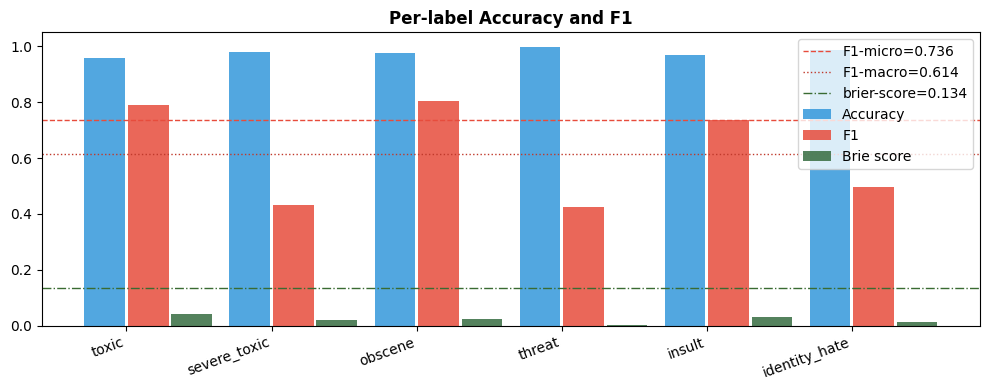

In [27]:
# Global exact-match accuracy
accuracy = corrects.mean()
print(f'Global exact-match accuracy: {accuracy:.4f}\n')

# Per-label accuracy and F1
label_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
accs = [(y_true[:,i] == y_pred[:,i]).mean() for i in range(num_labels)]
f1s  = [f1_score(y_true[:,i], y_pred[:,i], zero_division=0) for i in range(num_labels)]
brier_scores  = [brier_score_loss(y_true[:,i], y_pred[:,i]) for i in range(num_labels)]

f1_micro = f1_score(y_true, y_pred, average='micro',  zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro',  zero_division=0)
brier_score = brier_score_loss(y_true, y_pred)

print(f'  {"Label":15s} | {"Accuracy":>8s} | {"F1":>8s} | {"Brier Score":>8s}')
print('  ' + '-'*38)
for lbl, acc, f1, bs in zip(label_cols, accs, f1s, brier_scores):
    print(f'  {lbl:15s} | {acc:>8.4f} | {f1:>8.4f} | {bs:>8.4f}')
print('  ' + '-'*38)
print(f'  {"F1-micro":15s} | {" ":>8s} | {f1_micro:>8.4f}')
print(f'  {"F1-macro":15s} | {" ":>8s} | {f1_macro:>8.4f}')
print(f'  {"Brier score":15s} | {" ":>8s} | {brier_score:>8.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(num_labels)
ax.bar(x - 0.15, accs, 0.28, label='Accuracy', color='#3498db', alpha=0.85)
ax.bar(x + 0.15, f1s,  0.28, label='F1',       color='#e74c3c', alpha=0.85)
ax.bar(x + 0.45, brier_scores,  0.28, label='Brie score',       color="#366c40", alpha=0.85)
ax.axhline(f1_micro, linestyle='--', color='#e74c3c', linewidth=1, label=f'F1-micro={f1_micro:.3f}')
ax.axhline(f1_macro, linestyle=':',  color='#c0392b', linewidth=1, label=f'F1-macro={f1_macro:.3f}')
ax.axhline(brier_score, linestyle='dashdot',  color="#396b32", linewidth=1, label=f'brier-score={brier_score:.3f}')
ax.set_xticks(x)
ax.set_xticklabels(label_cols, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Per-label Accuracy and F1', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


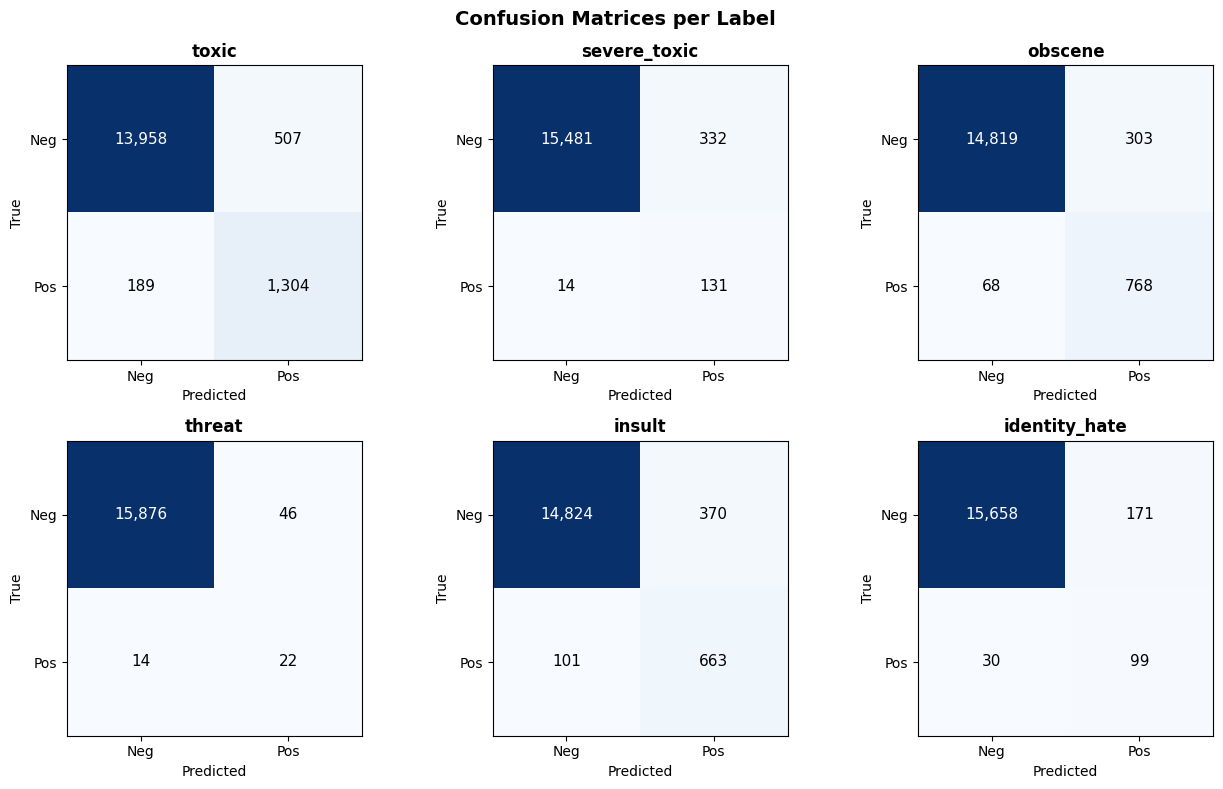

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, (lbl, ax) in enumerate(zip(label_cols, axes)):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])
    im = ax.imshow(cm, cmap='Blues')
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f'{cm[r,c]:,}', ha='center', va='center',
                    color='white' if cm[r,c] > cm.max()/2 else 'black', fontsize=11)
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Neg','Pos']); ax.set_yticklabels(['Neg','Pos'])

plt.suptitle('Confusion Matrices per Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Pearson r (uncertainty ↔ error): 0.740

   Bin |   Mean unc |   Accuracy
  --------------------------------
     0 |     0.0059 |     0.9975
     1 |     0.0061 |     0.9987
     2 |     0.0063 |     0.9975
     3 |     0.0065 |     0.9950
     4 |     0.0067 |     0.9950
     5 |     0.0070 |     0.9956
     6 |     0.0076 |     0.9950
     7 |     0.0094 |     0.9806
     8 |     0.0438 |     0.7975
     9 |     0.1484 |     0.3009

Top 20% most uncertain  → acc: 0.549
Top 20% most confident  → acc: 0.998


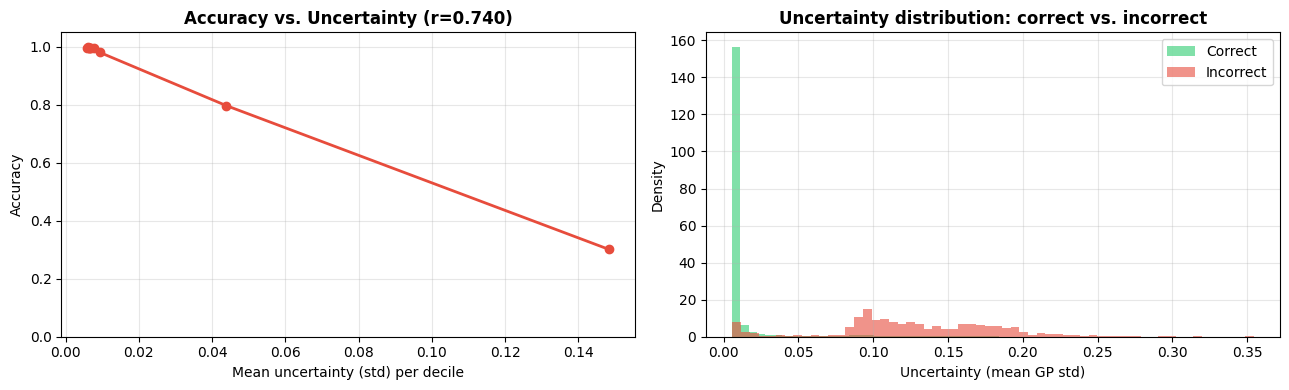

In [29]:
# Sort by uncertainty
order      = np.argsort(uncertainties)
unc_sorted = uncertainties[order]
corr_sorted= corrects[order]

# Pearson correlation uncertainty ↔ error
errors = 1 - corrects
r = np.corrcoef(uncertainties, errors)[0, 1]
print(f'Pearson r (uncertainty ↔ error): {r:.3f}')

# Accuracy by decile
n_bins = 10
bins   = np.array_split(np.arange(len(unc_sorted)), n_bins)
bin_unc  = [unc_sorted[b].mean() for b in bins]
bin_acc  = [corr_sorted[b].mean() for b in bins]

print(f'\n  {"Bin":>4s} | {"Mean unc":>10s} | {"Accuracy":>10s}')
print('  ' + '-'*32)
for i,(u,a) in enumerate(zip(bin_unc, bin_acc)):
    print(f'  {i:>4d} | {u:>10.4f} | {a:>10.4f}')

# Top-k
k = int(0.2 * len(all_samples))
acc_high = corrects[np.argsort(uncertainties)[-k:]].mean()
acc_low  = corrects[np.argsort(uncertainties)[:k]].mean()
print(f'\nTop 20% most uncertain  → acc: {acc_high:.3f}')
print(f'Top 20% most confident  → acc: {acc_low:.3f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(bin_unc, bin_acc, 'o-', color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Mean uncertainty (std) per decile')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'Accuracy vs. Uncertainty (r={r:.3f})', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)

axes[1].hist(uncertainties[corrects==1], bins=60, alpha=0.6, label='Correct',   color='#2ecc71', density=True)
axes[1].hist(uncertainties[corrects==0], bins=60, alpha=0.6, label='Incorrect', color='#e74c3c', density=True)
axes[1].set_xlabel('Uncertainty (mean GP std)')
axes[1].set_ylabel('Density')
axes[1].set_title('Uncertainty distribution: correct vs. incorrect', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [30]:
all_samples = []
for combo_list in combos.values():
    all_samples.extend(combo_list)

uncertainties = np.array([x["uncertainty"] for x in all_samples])
corrects = np.array([x["correct"] for x in all_samples]).astype(int)

# ordenar por incertidumbre
order = np.argsort(uncertainties)
unc_sorted = uncertainties[order]
corr_sorted = corrects[order]

# dividir en bins (ej: 10)
n_bins = 10
bins = np.array_split(np.arange(len(unc_sorted)), n_bins)

print("\nAccuracy por nivel de incertidumbre:")
for i, b in enumerate(bins):
    acc = corr_sorted[b].mean()
    unc_mean = unc_sorted[b].mean()
    print(f"Bin {i}: unc={unc_mean:.3f} | acc={acc:.3f}")


Accuracy por nivel de incertidumbre:
Bin 0: unc=0.006 | acc=0.997
Bin 1: unc=0.006 | acc=0.999
Bin 2: unc=0.006 | acc=0.997
Bin 3: unc=0.006 | acc=0.995
Bin 4: unc=0.007 | acc=0.995
Bin 5: unc=0.007 | acc=0.996
Bin 6: unc=0.008 | acc=0.995
Bin 7: unc=0.009 | acc=0.981
Bin 8: unc=0.044 | acc=0.797
Bin 9: unc=0.148 | acc=0.301


In [ ]:
top2_uncertain_per_combo = {}

for combo, samples in combos.items():
    top2 = sorted(samples, key=lambda x: x["uncertainty"], reverse=True)[:2]
    top2_uncertain_per_combo[combo] = top2

serializable = {
    str(combo): samples
    for combo, samples in top2_uncertain_per_combo.items()
}

with open("results_notebook/top2_uncertain_per_combo_unfreezed_weigths.json", "w", encoding="utf-8") as f:
    json.dump(serializable, f, ensure_ascii=False, indent=2)

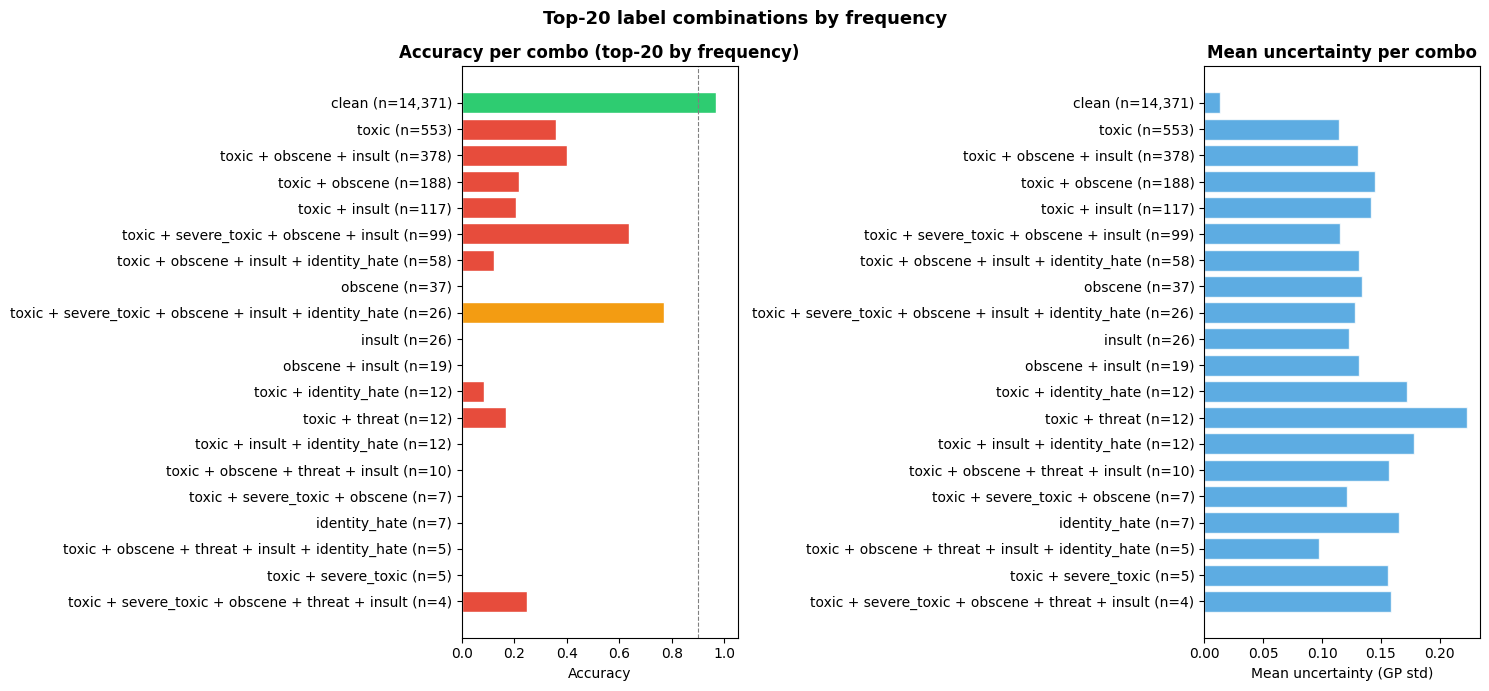

In [32]:
combo_stats = []
for combo, samples in combos.items():
    if not samples: continue
    combo_stats.append({
        'combo':   combo,
        'n':       len(samples),
        'acc':     np.mean([s['correct']     for s in samples]),
        'unc':     np.mean([s['uncertainty'] for s in samples]),
        'label':   ' + '.join(label_cols[i] for i,v in enumerate(combo) if v) or 'clean',
    })

combo_stats.sort(key=lambda x: -x['n'])
top_combos = combo_stats[:20]  # top-20 most frequent

labels_c = [f"{c['label']} (n={c['n']:,})" for c in top_combos]
accs_c   = [c['acc'] for c in top_combos]
uncs_c   = [c['unc'] for c in top_combos]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
colors_acc = ['#2ecc71' if a > 0.9 else '#f39c12' if a > 0.7 else '#e74c3c' for a in accs_c]
axes[0].barh(labels_c[::-1], accs_c[::-1], color=colors_acc[::-1], edgecolor='white')
axes[0].axvline(0.9, linestyle='--', color='gray', linewidth=0.8)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy per combo (top-20 by frequency)', fontweight='bold')
axes[0].set_xlim(0, 1.05)

axes[1].barh(labels_c[::-1], uncs_c[::-1], color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Mean uncertainty (GP std)')
axes[1].set_title('Mean uncertainty per combo', fontweight='bold')

plt.suptitle('Top-20 label combinations by frequency', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [33]:
def leet_speak(text):
    """Replace letters with visually similar digits (l33tspeak)."""
    return text.translate(str.maketrans('aeiost', '431057'))

def add_spaces(text):
    """Insert spaces between every character of long words."""
    return ' '.join(' '.join(w) if len(w) > 4 else w for w in text.split())

def unicode_homoglyphs(text):
    """Replace Latin letters with visually identical Cyrillic characters."""
    return text.translate(str.maketrans('aeoi', 'аеоі'))

def add_typos(text, rate=0.12, seed=42):
    """Randomly duplicate or drop characters."""
    rng, result = random.Random(seed), []
    for c in text:
        r = rng.random()
        if   r < rate/2:  pass
        elif r < rate:    result.extend([c, c])
        else:             result.append(c)
    return ''.join(result)

def punct_noise(text):
    """Intercalate dots between pairs of word characters."""
    return re.sub(r'(\w)(\w)', r'\1.\2', text)

def neutral_prefix(text):
    """Prepend an innocuous phrase to dilute toxicity signal."""
    return 'In my humble opinion, ' + text

TRANSFORMS = {
    'original':          lambda x: x,
    'leet_speak':        leet_speak,
    'add_spaces':        add_spaces,
    'unicode_homoglyphs':unicode_homoglyphs,
    'typos':             add_typos,
    'punct_noise':       punct_noise,
    'neutral_prefix':    neutral_prefix,
}
print('Perturbation functions:', list(TRANSFORMS.keys()))


Perturbation functions: ['original', 'leet_speak', 'add_spaces', 'unicode_homoglyphs', 'typos', 'punct_noise', 'neutral_prefix']


In [34]:
adv_corpus = []
for combo, samples in top2_uncertain_per_combo.items():
    for s in samples:
        adv_corpus.append({
            'text':        s['text'],
            'true_labels': s['combo_true'],
            'orig_preds':  s['combo_pred'],
            'orig_unc':    s['uncertainty'],
            'orig_correct':s['correct'],
            'combo':       combo,
            'combo_name':  ' + '.join(label_cols[i] for i,v in enumerate(combo) if v) or 'clean',
        })

print(f'Adversarial corpus: {len(adv_corpus)} samples')
print(f'  Covering {len(top2_uncertain_per_combo)} label combinations')
print(f'  Mean baseline uncertainty: {np.mean([s["orig_unc"] for s in adv_corpus]):.4f}')
print(f'  Baseline accuracy on these samples: {np.mean([s["orig_correct"] for s in adv_corpus]):.4f}')


Adversarial corpus: 51 samples
  Covering 29 label combinations
  Mean baseline uncertainty: 0.2112
  Baseline accuracy on these samples: 0.1373


In [35]:
adv_results = []  # one entry per corpus sample

for entry in tqdm.tqdm(adv_corpus):
    row = {
        'combo':      entry['combo'],
        'combo_name': entry['combo_name'],
        'text':       entry['text'],
        'true_labels':entry['true_labels'],
        'orig_preds': entry['orig_preds'],
        'orig_unc':   entry['orig_unc'],
        'orig_correct':entry['orig_correct'],
        'variants':   [],
    }

    for t_name, t_fn in TRANSFORMS.items():
        if t_name == 'original':
            # We already have the original prediction — reuse it
            row['variants'].append({
                'transform':   'original',
                'text':        entry['text'],
                'preds':       list(entry['orig_preds']),
                'uncertainty': entry['orig_unc'],
                'flipped':     False,
                'correct':     entry['orig_correct'],
            })
            continue

        perturbed = t_fn(entry['text'])
        result    = predict_with_uncertainty(
            model=model, tokenizer=tokenizer, text=perturbed,
            id2label=id2label, device=device, threshold=0.5, top_k=3)

        probs = np.array([p for _,p,_ in result['all_scores']])
        stds  = np.array([s for _,_,s in result['all_scores']])
        preds = (probs >= 0.5).astype(int).tolist()
        unc   = float(stds.mean())

        row['variants'].append({
            'transform':   t_name,
            'text':        perturbed,
            'probs':       probs.tolist(),
            'stds':        stds.tolist(),
            'preds':       preds,
            'uncertainty': unc,
            'flipped':     preds != list(entry['orig_preds']),
            'correct':     bool(np.array_equal(preds, list(entry['true_labels']))),
            'unc_delta':   unc - entry['orig_unc'],  # +ve = more uncertain after perturbation
        })

    adv_results.append(row)

print(f'Done. {len(adv_results)} samples evaluated.')


100%|██████████| 51/51 [00:12<00:00,  4.00it/s]

Done. 51 samples evaluated.


  Transform                 |  Flip rate |  Mean Δunc |   Accuracy
  ----------------------------------------------------------------
  leet_speak                |     96.1%  |    -0.1145 |     0.0980
  add_spaces                |     76.5%  |    -0.0454 |     0.0784
  unicode_homoglyphs        |     94.1%  |    -0.1292 |     0.0588
  typos                     |     88.2%  |    -0.0823 |     0.1373
  punct_noise               |     94.1%  |    -0.0677 |     0.0392
  neutral_prefix            |     43.1%  |    -0.0122 |     0.2549


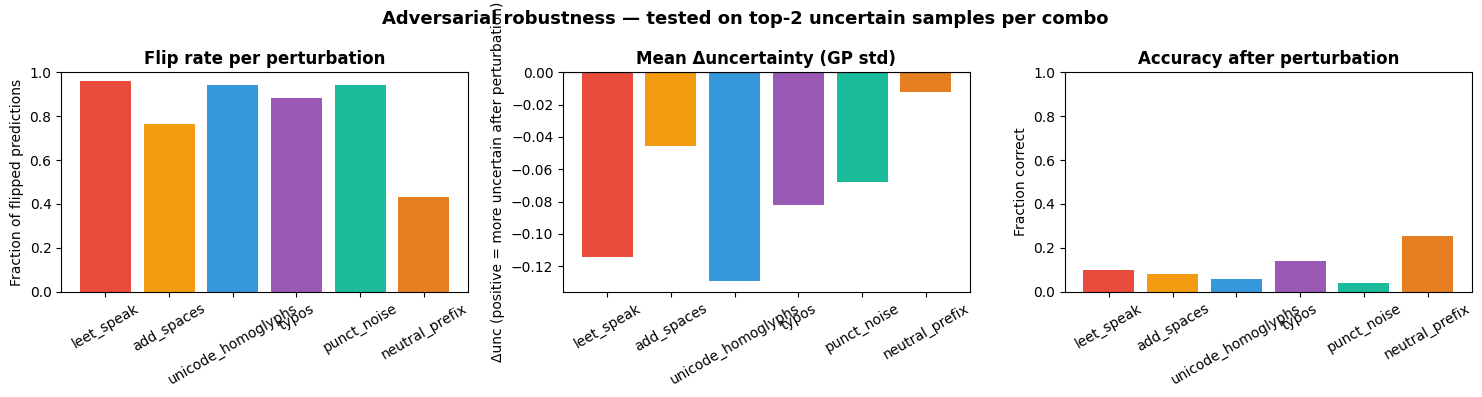

In [36]:
transform_names = [t for t in TRANSFORMS.keys() if t != 'original']

summary = {}
for t_name in transform_names:
    flips, delta_uncs, accs = [], [], []
    for row in adv_results:
        v = next(x for x in row['variants'] if x['transform'] == t_name)
        flips.append(int(v['flipped']))
        delta_uncs.append(v['unc_delta'])
        accs.append(int(v['correct']))
    summary[t_name] = {
        'flip_rate': np.mean(flips),
        'mean_delta_unc': np.mean(delta_uncs),
        'accuracy': np.mean(accs),
    }

print(f'  {"Transform":25s} | {"Flip rate":>10s} | {"Mean Δunc":>10s} | {"Accuracy":>10s}')
print('  ' + '-'*64)
for t, s in summary.items():
    print(f'  {t:25s} | {s["flip_rate"]:>9.1%}  | {s["mean_delta_unc"]:>+10.4f} | {s["accuracy"]:>10.4f}')

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
t_labels = list(summary.keys())
colors   = ['#e74c3c','#f39c12','#3498db','#9b59b6','#1abc9c','#e67e22']

axes[0].bar(t_labels, [summary[t]['flip_rate']      for t in t_labels], color=colors)
axes[0].set_title('Flip rate per perturbation', fontweight='bold')
axes[0].set_ylabel('Fraction of flipped predictions')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(t_labels, [summary[t]['mean_delta_unc'] for t in t_labels], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Mean Δuncertainty (GP std)', fontweight='bold')
axes[1].set_ylabel('Δunc (positive = more uncertain after perturbation)')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(t_labels, [summary[t]['accuracy']       for t in t_labels], color=colors)
axes[2].set_title('Accuracy after perturbation', fontweight='bold')
axes[2].set_ylabel('Fraction correct')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Adversarial robustness — tested on top-2 uncertain samples per combo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Flipped predictions  — mean Δunc: -0.0926  (n=251)
Stable  predictions  — mean Δunc: +0.0039  (n=55)

Welch t-test: t=-7.217, p=0.0000
→ GP uncertainty is a statistically significant predictor of prediction flips.


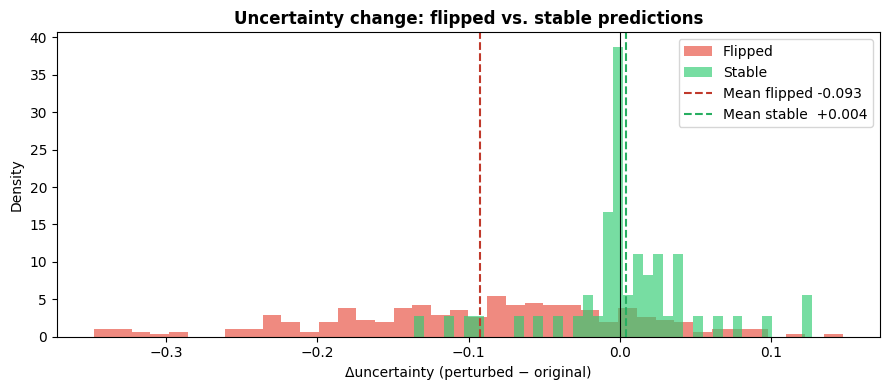

In [37]:
delta_flipped   = []
delta_stable    = []

for row in adv_results:
    for v in row['variants']:
        if v['transform'] == 'original': continue
        if v['flipped']:  delta_flipped.append(v['unc_delta'])
        else:             delta_stable.append(v['unc_delta'])

print(f'Flipped predictions  — mean Δunc: {np.mean(delta_flipped):+.4f}  (n={len(delta_flipped)})')
print(f'Stable  predictions  — mean Δunc: {np.mean(delta_stable):+.4f}  (n={len(delta_stable)})')

from scipy import stats
t_stat, p_val = stats.ttest_ind(delta_flipped, delta_stable)
print(f'\nWelch t-test: t={t_stat:.3f}, p={p_val:.4f}')
print('→ GP uncertainty is a statistically significant predictor of prediction flips.' if p_val < 0.05
      else '→ No statistically significant difference detected.')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(delta_flipped, bins=40, alpha=0.65, label='Flipped', color='#e74c3c', density=True)
ax.hist(delta_stable,  bins=40, alpha=0.65, label='Stable',  color='#2ecc71', density=True)
ax.axvline(np.mean(delta_flipped), color='#c0392b', linestyle='--', linewidth=1.5, label=f'Mean flipped {np.mean(delta_flipped):+.3f}')
ax.axvline(np.mean(delta_stable),  color='#27ae60', linestyle='--', linewidth=1.5, label=f'Mean stable  {np.mean(delta_stable):+.3f}')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Δuncertainty (perturbed − original)')
ax.set_ylabel('Density')
ax.set_title('Uncertainty change: flipped vs. stable predictions', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


In [38]:
for t_name in transform_names:
    flipped_cases = [
        row for row in adv_results
        if next(x for x in row['variants'] if x['transform']==t_name)['flipped']
    ]
    if not flipped_cases:
        print(f'\n[{t_name}] No flips.')
        continue
    print(f'\n' + '='*60)
    print(f'Transform: {t_name}  ({len(flipped_cases)} flips / {len(adv_results)} samples)')
    print('='*60)
    for row in flipped_cases:
        v = next(x for x in row['variants'] if x['transform']==t_name)
        print(f'\n  Combo      : {row["combo"]}  [{row["combo_name"]}]')
        print(f'  True labels: {list(row["true_labels"])}')
        print(f'  Orig pred  : {list(row["orig_preds"])}  (correct={row["orig_correct"]})')
        print(f'  New  pred  : {v["preds"]}')
        print(f'  Orig unc   : {row["orig_unc"]:.4f}  →  New unc: {v["uncertainty"]:.4f}  (Δ={v["unc_delta"]:+.4f})')
        print(f'  Original   : {row["text"][:100]}')
        print(f'  Perturbed  : {v["text"][:100]}')



Transform: leet_speak  (49 flips / 51 samples)

  Combo      : (0, 0, 0, 0, 0, 0)  [clean]
  True labels: [0, 0, 0, 0, 0, 0]
  Orig pred  : [1, 0, 0, 0, 0, 0]  (correct=False)
  New  pred  : [0, 0, 0, 0, 0, 0]
  Orig unc   : 0.2988  →  New unc: 0.0785  (Δ=-0.2203)
  Original   : inappropriate block
  Perturbed  : 1n4ppr0pr1473 bl0ck

  Combo      : (0, 0, 0, 0, 0, 0)  [clean]
  True labels: [0, 0, 0, 0, 0, 0]
  Orig pred  : [1, 0, 1, 1, 1, 0]  (correct=False)
  New  pred  : [0, 0, 0, 0, 0, 0]
  Orig unc   : 0.2965  →  New unc: 0.1108  (Δ=-0.1857)
  Original   : indeed, he is not surprised that that your fascist state was repeatedly elected nekolirkta as the bi
  Perturbed  : 1nd33d, h3 15 n07 5urpr153d 7h47 7h47 y0ur f45c157 57473 w45 r3p3473dly 3l3c73d n3k0l1rk74 45 7h3 b1

  Combo      : (1, 1, 1, 0, 1, 0)  [toxic + severe_toxic + obscene + insult]
  True labels: [1, 1, 1, 0, 1, 0]
  Orig pred  : [1, 0, 1, 0, 1, 0]  (correct=False)
  New  pred  : [0, 0, 0, 0, 0, 0]
  Orig unc   : 0.

In [ ]:
# Build the low-uncertainty corpus (2 most confident per combo)
low_unc_corpus = []

for combo, samples in combos.items():
    bottom2 = sorted(samples, key=lambda x: x['uncertainty'])[:2]
    for s in bottom2:
        low_unc_corpus.append({
            'text':        s['text'],
            'true_labels': s['combo_true'],
            'orig_preds':  s['combo_pred'],
            'orig_unc':    s['uncertainty'],
            'orig_correct':s['correct'],
            'combo':       combo,
            'combo_name':  ' + '.join(label_cols[i] for i,v in enumerate(combo) if v) or 'clean',
        })

print(f'Low-uncertainty corpus: {len(low_unc_corpus)} samples')
print(f'  Covering {len(combos)} label combinations')
print(f'  Mean baseline uncertainty: {np.mean([s["orig_unc"] for s in low_unc_corpus]):.4f}')
print(f'  Baseline accuracy on these samples: {np.mean([s["orig_correct"] for s in low_unc_corpus]):.4f}')

top2_certain_per_combo = {}

for combo, samples in combos.items():
    top2 = sorted(samples, key=lambda x: x["uncertainty"], reverse=False)[:2]
    top2_certain_per_combo[combo] = top2

serializable = {
    str(combo): samples
    for combo, samples in top2_certain_per_combo.items()
}

with open("results_notebook/top2_certain_per_combo_unfreezed_weights.json", "w", encoding="utf-8") as f:
    json.dump(serializable, f, ensure_ascii=False, indent=2)

Low-uncertainty corpus: 51 samples
  Covering 29 label combinations
  Mean baseline uncertainty: 0.0791
  Baseline accuracy on these samples: 0.1176


100%|██████████| 51/51 [00:14<00:00,  3.52it/s]



Transform                 | High-unc flip | Low-unc flip | High-unc Δunc | Low-unc Δunc
------------------------------------------------------------------------------------
leet_speak                |        96.1%  |       52.9%  |       -0.1145 |      +0.0328
add_spaces                |        76.5%  |       74.5%  |       -0.0454 |      +0.0774
unicode_homoglyphs        |        94.1%  |       49.0%  |       -0.1292 |      +0.0187
typos                     |        88.2%  |       49.0%  |       -0.0823 |      +0.0259
punct_noise               |        94.1%  |       94.1%  |       -0.0677 |      +0.0766
neutral_prefix            |        43.1%  |        9.8%  |       -0.0122 |      +0.0032


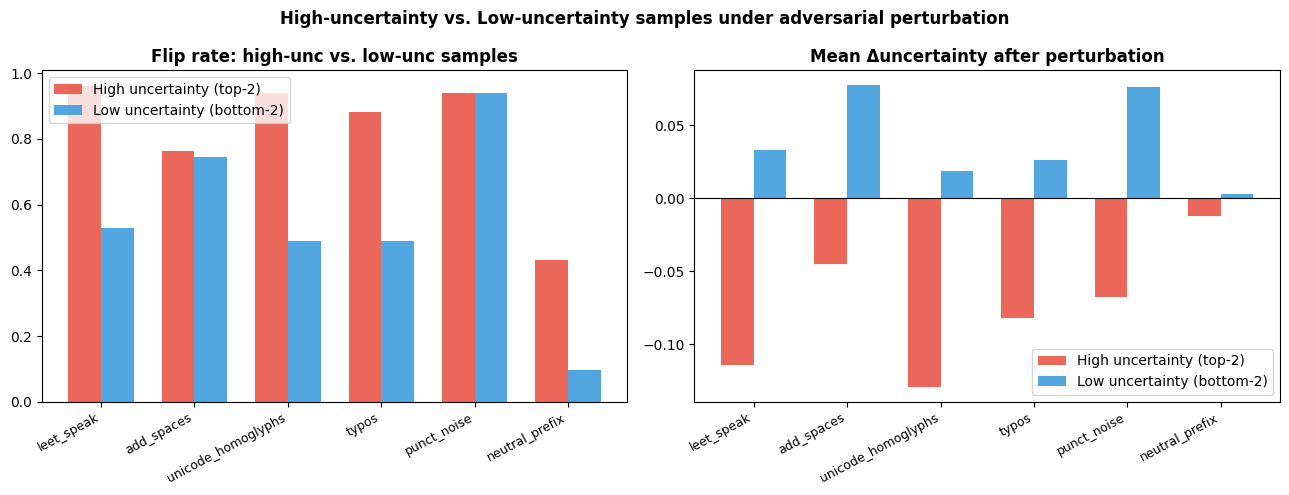

In [40]:
# Evaluate perturbations on the low-uncertainty corpus
low_unc_results = []

for entry in tqdm.tqdm(low_unc_corpus):
    row = {**entry, 'variants': []}
    for t_name, t_fn in TRANSFORMS.items():
        if t_name == 'original':
            row['variants'].append({
                'transform': 'original', 'text': entry['text'],
                'preds': list(entry['orig_preds']), 'uncertainty': entry['orig_unc'],
                'flipped': False, 'correct': entry['orig_correct'], 'unc_delta': 0.0,
            })
            continue
        perturbed = t_fn(entry['text'])
        result    = predict_with_uncertainty(
            model=model, tokenizer=tokenizer, text=perturbed,
            id2label=id2label, device=device, threshold=0.5, top_k=3)
        probs = np.array([p for _,p,_ in result['all_scores']])
        stds  = np.array([s for _,_,s in result['all_scores']])
        preds = (probs >= 0.5).astype(int).tolist()
        unc   = float(stds.mean())
        row['variants'].append({
            'transform': t_name, 'text': perturbed,
            'probs': probs.tolist(), 'stds': stds.tolist(), 'preds': preds,
            'uncertainty': unc, 'flipped': preds != list(entry['orig_preds']),
            'correct': bool(np.array_equal(preds, list(entry['true_labels']))),
            'unc_delta': unc - entry['orig_unc'],
        })
    low_unc_results.append(row)

# ── Comparative summary ──────────────────────────────────────────────────────
transform_names = [t for t in TRANSFORMS if t != 'original']

print(f'\n{"Transform":25s} | {"High-unc flip":>13s} | {"Low-unc flip":>12s} | {"High-unc Δunc":>13s} | {"Low-unc Δunc":>12s}')
print('-' * 84)

for t_name in transform_names:
    def stats(results):
        flips, deltas = [], []
        for row in results:
            v = next(x for x in row['variants'] if x['transform'] == t_name)
            flips.append(int(v['flipped']))
            deltas.append(v['unc_delta'])
        return np.mean(flips), np.mean(deltas)

    hf, hd = stats(adv_results)
    lf, ld = stats(low_unc_results)
    print(f'{t_name:25s} | {hf:>12.1%}  | {lf:>11.1%}  | {hd:>+13.4f} | {ld:>+12.4f}')

# ── Visual comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(transform_names))
w = 0.35

for ax, metric, title, fmt in [
    (axes[0], 'flip_rate',      'Flip rate: high-unc vs. low-unc samples',      '{:.1%}'),
    (axes[1], 'mean_delta_unc', 'Mean Δuncertainty after perturbation',          '{:+.4f}'),
]:
    high_vals, low_vals = [], []
    for t in transform_names:
        def get(results, key):
            vals = []
            for row in results:
                v = next(x for x in row['variants'] if x['transform'] == t)
                vals.append(int(v['flipped']) if key == 'flip_rate' else v['unc_delta'])
            return np.mean(vals)
        high_vals.append(get(adv_results,     metric))
        low_vals.append( get(low_unc_results, metric))

    ax.bar(x - w/2, high_vals, w, label='High uncertainty (top-2)', color='#e74c3c', alpha=0.85)
    ax.bar(x + w/2, low_vals,  w, label='Low uncertainty (bottom-2)', color='#3498db', alpha=0.85)
    if metric == 'mean_delta_unc':
        ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(transform_names, rotation=28, ha='right', fontsize=9)
    ax.legend()

plt.suptitle('High-uncertainty vs. Low-uncertainty samples under adversarial perturbation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()